In [1]:
import matplotlib.pyplot as plt
import matplotlib.animationformula
import numpy as np
import scipy as sp

%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


## Cross - Correlation

For two continuous functions $a(t)$ and $b(t)$, the correlation is defined with the shift operator $\tau$ as:

$$  a(t) \star  b(t) = \int_{-\infty}^{\infty} a(t + \tau) b(\tau) d \tau$$

In the discrete case:
$$  a[n] \star  b[n] = \sum_{m=-\infty}^{\infty} a[n + m] b[m]$$


Note the similarity to the convolution - only the sign of the shift operator $\tau$ has changed. This flip also means that the cross correlation is not commutative:

$$ a(t) \star  b(t) \neq b(t) \star  a(t)$$

Cross correlation can give information on the similarity of two signals and is thus frequently used in audio DSP.

------


# Example: Correlation of Random Signals

The below example shows the result of a cross correlation between to different random sequences $b(t)$ and $b(t)$. As with convolution, the length of the signal is the lenght of both input signals combined -1.
Although the signals are not identical, the cross correlation function has its maximum in the center.

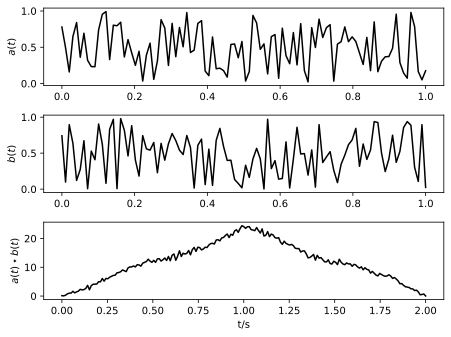

In [2]:
fig = plt.figure()

h        = np.random.random(size=(100,1))
x        = np.random.random(size=(100,1))

y = sp.signal.correlate(x,h,mode="full")

t = np.linspace(0,1,100)

ax = plt.subplot(3,1,1)
ax.plot(t,h, 'k')
ax.set_ylabel('$a(t)$')
ax = plt.subplot(3,1,2)
ax.plot(t,x, 'k')
ax.set_ylabel('$b(t)$')
ax = plt.subplot(3,1,3)
ax.plot(np.linspace(0,2,199),y, 'k')
ax.set_ylabel('$a(t) \star b(t)$')
ax.set_xlabel('t/s')

fig.tight_layout()

-----

# Comparison with Convolution

The following example shows how correlation and convolution work differently for two input signals.
$a(t)$ is a sine wave and $b(t)$ a cosine wave, both with the same amplitude and frequency.



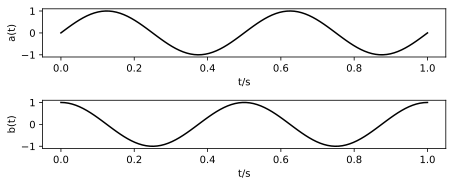

In [3]:
fig = plt.figure()
plt.tight_layout(pad=1.1)

t = np.linspace(0,1,100)

h        = np.sin(2*np.pi*t*2)
x        = np.cos(2*np.pi*t*2)


t = np.linspace(0,1,100)

ax = plt.subplot(4,1,1)
ax.plot(t,h, 'k')
ax.set_ylabel('a(t)')
ax.set_xlabel('t/s')

ax = plt.subplot(4,1,2)
ax.plot(t,x, 'k')
ax.set_ylabel('b(t)')
ax.set_xlabel('t/s')

fig.tight_layout()

**Correlation:**

To inspect the commutative properties, both $a \star b$ and '$b \star a$ ar calculated and plotted.
The results of both correlations are not equal:

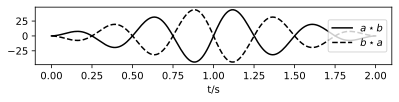

In [4]:
y = sp.signal.correlate(h,x,mode="full")
y2 = sp.signal.correlate(x,h,mode="full")

ax = plt.subplot(4,1,3)
ax.plot(np.linspace(0,2,199),y, 'k')
ax.plot(np.linspace(0,2,199),y2, 'k--')
ax.set_xlabel('t/s')
ax.legend(['$a \star b$','$b \star a$'],loc='right');

**Convolution:**

As for the correlation, both $a * b$ and '$b * a$ ar calculated and plotted.
The results of both correlations are identical:

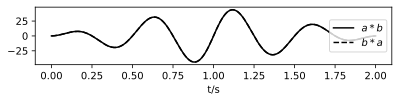

In [5]:
y = sp.signal.convolve(h,x,mode="full")
y2 = sp.signal.convolve(x,h,mode="full")

ax = plt.subplot(4,1,4)
ax.plot(np.linspace(0,2,199),y, 'k')
ax.plot(np.linspace(0,2,199),y2, 'k--')
ax.set_xlabel('t/s')
ax.legend(['$a * b$','$b * a$'],loc='right')

